# 02 · Hyetograph classification — PCA + K-Means

Events are classified by their **temporal shape**, not by the spatial pattern of Pmax across gauges. Each hyetograph is discretised into **100 normalised timesteps** and PCA + K-Means is applied to group events into representative shape types.  

The paper (Navas et al., 2024) obtains **K = 100 types** from the 1,761 × 68 matrix (events × 4 parameters × 17 gauges). The **`Type`** column in each gauge of the CSV stores the resulting integer class label.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'm30_manzanares'

EVENTS_DIR   = DATA_ROOT / 'events'
RESULTS_DIR  = DATA_ROOT / 'results'
STATIONS_DIR = DATA_ROOT / 'stations'

print('DATA_ROOT:', DATA_ROOT)

T_VALS   = [2, 5, 10, 20, 50, 100, 500]
N_STAT   = 17
LAM      = 5.17    # Poisson rate (events/year)
XS_PT    = 6262    # Toledo Bridge cross-section
XS_R9    = 4112    # Weir No.9 cross-section


DATA_ROOT: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/m30_manzanares


Types in P_27 data: 25  (paper uses K=100 fitted on 1,761 historical events)
Type values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


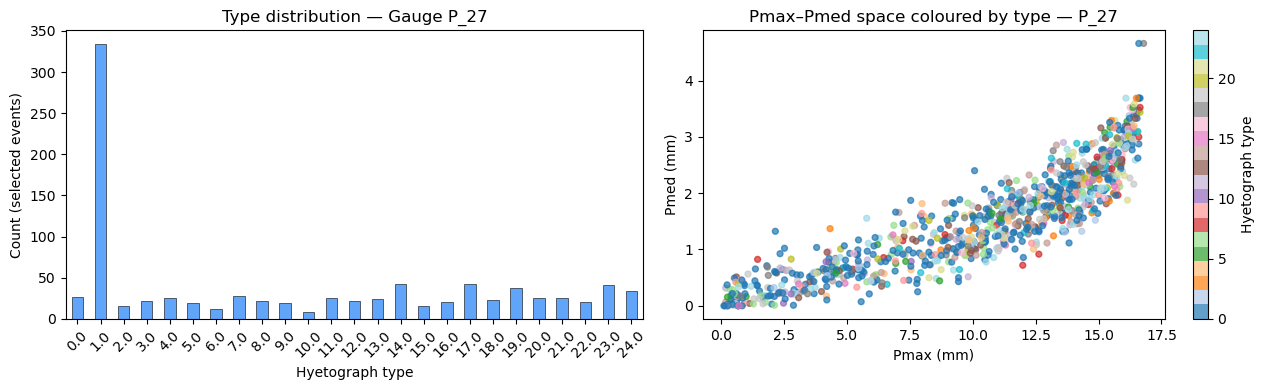

In [2]:
events   = pd.read_csv(EVENTS_DIR / 'events_selected.csv', index_col=0)
stations = pd.read_csv(STATIONS_DIR / 'stations.csv', index_col=0)
stations.columns = ['X', 'Y', 'Z']

# Reference gauge: P_27 (station 1)
p27 = events[['Pmax1','Pmed1','Duracion1','Tipo1']].copy()
p27 = p27[p27['Pmax1'] > 0].reset_index(drop=True)
p27.columns = ['Pmax','Pmed','Duration','Type']

n_types = p27['Type'].nunique()
print(f'Types in P_27 data: {n_types}  '
      f'(paper uses K=100 fitted on 1,761 historical events)')
print(f'Type values: {[int(t) for t in sorted(p27["Type"].unique())]}')

# Type frequency
tipo_counts = p27['Type'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tipo_counts.plot(kind='bar', ax=axes[0], color='#60a5fa', edgecolor='k', lw=0.4)
axes[0].set_xlabel('Hyetograph type'); axes[0].set_ylabel('Count (selected events)')
axes[0].set_title('Type distribution — Gauge P_27')
axes[0].tick_params(axis='x', rotation=45)

sc = axes[1].scatter(p27['Pmax'], p27['Pmed'],
                     c=p27['Type'], cmap='tab20', s=18, alpha=0.7)
axes[1].set_xlabel('Pmax (mm)'); axes[1].set_ylabel('Pmed (mm)')
axes[1].set_title('Pmax–Pmed space coloured by type — P_27')
plt.colorbar(sc, ax=axes[1], label='Hyetograph type')
plt.tight_layout(); plt.show()

## Characteristics by type

Types with highest median Pmax:
      Pmax_med  Dur_med
Type                   
15.0      14.5    110.0
3.0       13.7    100.3
8.0       13.6     84.2
16.0      13.4     69.3
18.0      13.3     81.3


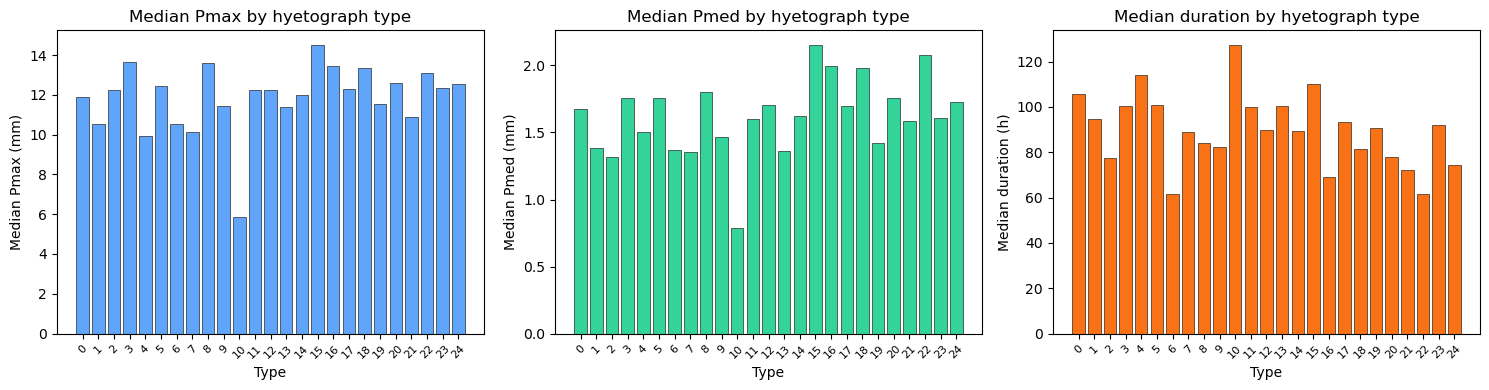

In [3]:
tipos  = sorted(p27['Type'].unique())
groups = p27.groupby('Type')
pmax_med = [groups.get_group(t)['Pmax'].median()     for t in tipos]
pmed_med = [groups.get_group(t)['Pmed'].median()     for t in tipos]
dur_med  = [groups.get_group(t)['Duration'].median() for t in tipos]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kw = dict(edgecolor='k', lw=0.4)
x  = range(len(tipos))
xt = [int(t) for t in tipos]

axes[0].bar(x, pmax_med, color='#60a5fa', **kw)
axes[0].set_xticks(x); axes[0].set_xticklabels(xt, rotation=45, fontsize=8)
axes[0].set_xlabel('Type'); axes[0].set_ylabel('Median Pmax (mm)')
axes[0].set_title('Median Pmax by hyetograph type')

axes[1].bar(x, pmed_med, color='#34d399', **kw)
axes[1].set_xticks(x); axes[1].set_xticklabels(xt, rotation=45, fontsize=8)
axes[1].set_xlabel('Type'); axes[1].set_ylabel('Median Pmed (mm)')
axes[1].set_title('Median Pmed by hyetograph type')

axes[2].bar(x, dur_med,  color='#f97316', **kw)
axes[2].set_xticks(x); axes[2].set_xticklabels(xt, rotation=45, fontsize=8)
axes[2].set_xlabel('Type'); axes[2].set_ylabel('Median duration (h)')
axes[2].set_title('Median duration by hyetograph type')

plt.tight_layout(); plt.show()

df_t = pd.DataFrame({'Type': tipos, 'Pmax_med': pmax_med, 'Dur_med': dur_med}).set_index('Type')
print('Types with highest median Pmax:')
print(df_t.sort_values('Pmax_med', ascending=False).head(5).round(1))